In [83]:
from multiprocessing import Pool
import subprocess
import yaml
import os
import sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import tempfile
import copy
from datetime import datetime
import pandas as pd
from collections import Counter
import numpy as np
import threading
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from joblib import load
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import cv2

In [ ]:
selected_FE = 'clip-vit-large-patch14'  # Example feature extractor, can be changed
input_dir=source_path+f'\\outputs\\online_deep_feature_extraction\\{selected_FE}\\representation_extraction\\extracted_representation'
source_file_test=None
data_augmentation = False
suffix = '_augmented' if data_augmentation else ''
kind = 'patches_224'  # Example kind, can be changed
train_filename,val_filename = file_IO.load_input_files(source_path,selected_FE,kind,suffix)

use_external_validation = True
if use_external_validation:
    validation_mode = 'val_only'  # 'kfold_train_only', 'val_only', '1fold_train_only'
else:
    validation_mode = '1fold_train_only'  # 'kfold_train_only', 'val_only', '1fold_train_only'
selected_classification_head = 'MLPClassifier2'#'TransformerClassifier'#'1DCNNClassifier'#'MLPClassifier2'
model_parameters = {
    'n_neurons':128,
    'dropout':0.2,
}
head_type = 'pytorch'  # 'sklearn' or 'pytorch'
list_of_metrics = ['majority_vote', 'weighted_vote', 'most_probable']

#see from training logs ad set by hand
extra_view=False
extra_integration_mode = 'concat'  # 'concat' or 'add'
aggregation_mode = None #'mean'  # 'mean' or 'max'
if extra_view:
    extra_train_filename, extra_val_filename = file_IO.load_input_files(source_path,selected_FE,kind='body',suffix='')
else:
    extra_train_filename, extra_val_filename = None, None

selected_metric='weighted_vote'
if kind == 'body':
    selected_metric = 'most_probable'  # Use the metric you want to analyze

args = script_launching.DotDict(
        data_augmentation=data_augmentation,
        use_external_validation=use_external_validation,
        validation_mode=validation_mode,
        selected_classification_head=selected_classification_head,
        selected_FE=selected_FE,
        head_type=head_type,
        extra_view=extra_view,
        extra_integration_mode=extra_integration_mode,
        aggregation_mode=aggregation_mode,
        train_filename=train_filename,
        val_filename=val_filename,
        extra_train_filename=extra_train_filename,
        extra_val_filename=extra_val_filename,
        selected_metric=selected_metric,
        #script_mode='standalone'
    )

In [ ]:
classification_head, val_df = data_loading.load_classification_head(selected_FE,selected_classification_head,head_type,
                                                                    validation_mode,train_filename, source_path,**model_parameters)
if use_external_validation:
    val_df = pd.read_csv(val_filename) 
    val_df['train'] = 0  # Mark validation data
if extra_view:
    val_df_extra = pd.read_csv(extra_val_filename)
    if not(use_external_validation):
        _, val_df_extra = data_loading.load_classification_head(selected_FE,selected_classification_head,head_type,validation_mode,extra_train_filename,source_path)
    val_df = dataframes.merge_dfs(val_df, val_df_extra, mode=extra_integration_mode)
val_df = dataframes.aggregate_dfs(val_df,mode=aggregation_mode)

aggregating patches, length before: 5680
length after: 5680


In [102]:
res_df=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type)

Accuracy for individual patches: 0.7051056338028169
Accuracy for majority_vote: 0.7676056338028169
Accuracy for weighted_vote: 0.7605633802816901
Accuracy for most_probable: 0.7535211267605634


## sub-accuracy on wrong and correct pages

In [51]:
failed=res_df[res_df['weighted_vote']!= res_df['grouped_true']]
correct = res_df[res_df['weighted_vote'] == res_df['grouped_true']]

In [44]:
failed[['male','y_pred']].head()

,male,y_pred
320,0,1
321,0,1
322,0,1
323,0,1
324,0,1


In [52]:
print('accuracy on failed',len(failed[failed['male']==failed['y_pred']])/len(failed))
print('accuracy on correct',len(correct[correct['male']==correct['y_pred']])/len(correct))

accuracy on failed 0.3211864406779661
accuracy on correct 0.7766666666666666


In [33]:
cols_to_drop = [c for c in res_df.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
print(f"Columns to drop: {cols_to_drop}")

Columns to drop: ['writer', 'isEng', 'same_text', 'file_name', 'male', 'Usage', 'x', 'y', 'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'train', 'page', 'patch_num', 'y_prob', 'y_pred', 'grouped_true', 'majority_vote', 'majority_vote_uncertainty', 'weighted_vote', 'weighted_vote_uncertainty', 'most_probable', 'most_probable_uncertainty']


In [ ]:
c_of_interest=['page','male','y_pred','y_prob','grouped_true','weighted_vote','majority_vote','weighted_vote_uncertainty']
test = res_df[c_of_interest].copy()
display(test[test['page'] == 60])

,page,male,y_pred,y_prob,grouped_true,weighted_vote,majority_vote,weighted_vote_uncertainty
1200,60,0,0,0.009928,0,0,0,1.0
1201,60,0,0,0.003392,0,0,0,1.0
1202,60,0,0,0.001549,0,0,0,1.0
1203,60,0,0,0.004528,0,0,0,1.0
1204,60,0,0,0.014960,0,0,0,1.0
1205,60,0,0,0.005881,0,0,0,1.0
1206,60,0,0,0.016971,0,0,0,1.0
1207,60,0,0,0.004005,0,0,0,1.0
1208,60,0,0,0.006588,0,0,0,1.0
1209,60,0,0,0.036278,0,0,0,1.0


## descriptive statistics

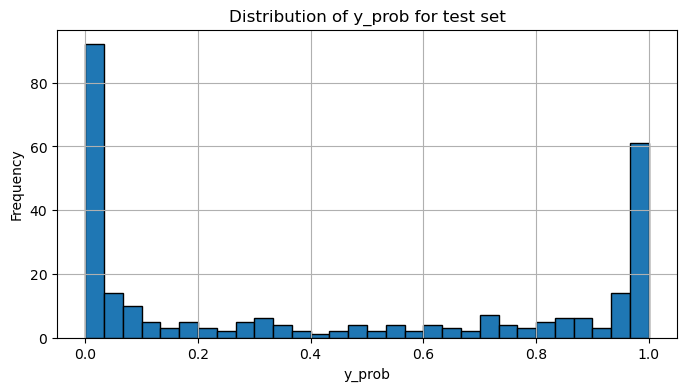

In [61]:
#probability distribution
res_df[res_df['train']==0]['y_prob'].describe()
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
res_df[res_df['train']==0]['y_prob'].hist(bins=30, edgecolor='black')
plt.title('Distribution of y_prob for test set')
plt.xlabel('y_prob')
plt.ylabel('Frequency')
plt.show()

In [62]:
#descriptive statistics for uncertainty
res_df[res_df['train']==0][[metric+'_uncertainty' for metric in list_of_metrics]].describe()

,majority_vote_uncertainty,weighted_vote_uncertainty,most_probable_uncertainty
count,284.0,284.0,284.000000
mean,0.0,1.0,0.801676
std,0.0,0.0,0.276877
min,0.0,1.0,0.005420
25%,0.0,1.0,0.676313
50%,0.0,1.0,0.952705
75%,0.0,1.0,0.999113
max,0.0,1.0,1.000000


In [63]:

print(len(res_df[(res_df['train']==0) & (res_df['male']==0)])/len(res_df[res_df['train']==0]))

0.6056338028169014


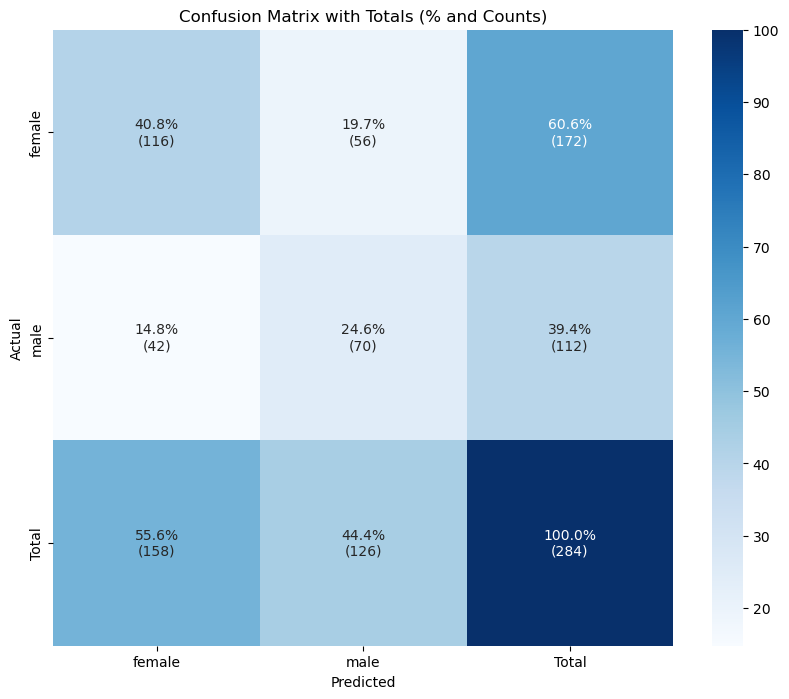

In [ ]:
# confusion matrix
grouped_res = res_df[res_df['train']==0].groupby('page').first()
true_values = grouped_res['grouped_true']
pred_values = grouped_res[selected_metric]
prob_values = grouped_res[f'{selected_metric}_uncertainty']
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Sample confusion matrix
labels = ['female', 'male']
conf = confusion_matrix(true_values, pred_values)

# Compute row and column totals
row_sums = conf.sum(axis=1, keepdims=True)
col_sums = conf.sum(axis=0, keepdims=True)
total = conf.sum()

# Build extended matrix with totals
conf_ext = np.vstack([conf, col_sums])             # Add totals row
conf_ext = np.hstack([conf_ext, np.append(row_sums, total).reshape(-1, 1)])  # Add totals column

# Convert to percentages
conf_ext_percent = conf_ext / total * 100

# Create labels for display (percentages + raw counts)
annot = np.empty_like(conf_ext).astype(str)
for i in range(conf_ext.shape[0]):
    for j in range(conf_ext.shape[1]):
        count = conf_ext[i, j]
        percent = conf_ext_percent[i, j]
        annot[i, j] = f'{percent:.1f}%\n({int(count)})'

# Define labels with "Total"
xticks = labels + ['Total']
yticks = labels + ['Total']

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(conf_ext_percent, annot=annot, fmt='', cmap='Blues', xticklabels=xticks, yticklabels=yticks)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Totals (% and Counts)")
plt.show()

In [65]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(true_values, pred_values, target_names=labels))
# accuracy score
accuracy = accuracy_score(true_values, pred_values)
print(f'Accuracy: {accuracy:.4f}')
#precision = TP/(TP + FP)
#recall = TP/(TP + FN)

              precision    recall  f1-score   support

      female       0.73      0.67      0.70       172
        male       0.56      0.62      0.59       112

    accuracy                           0.65       284
   macro avg       0.64      0.65      0.65       284
weighted avg       0.66      0.65      0.66       284

Accuracy: 0.6549


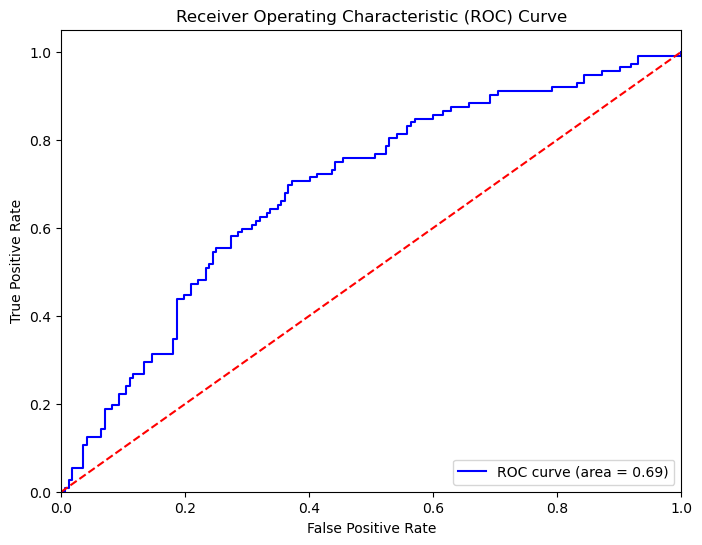

In [66]:
# ROC curve and AUC
from sklearn.metrics import roc_curve, auc
true_values = res_df[res_df['train']==0]['male']
prob_values = res_df[res_df['train']==0]['y_prob']
fpr, tpr, thresholds = roc_curve(true_values, prob_values)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
#TPR=Recall=TP/(TP + FN)
#FPR=FP/(FP + TN)

## select instances

In [71]:
selected = evaluation_utils.select_instances(res_df, selected_metric)

base_dir=source_path + f'/outputs/online_deep_feature_extraction/{selected_FE}/representation_extraction/'
if head_type == 'sklearn':
    search_dir = base_dir+f'sklearn_model_trained_on_rep/{selected_classification_head}/'
else:
    search_dir = base_dir+f'torch_model_trained_on_rep/{selected_classification_head}/'
selected.to_csv(search_dir+f'selected_instances_{selected_metric}.csv', index=False)
file_IO.save_args(args,search_dir)  # Save the arguments to a file

Percentiles for majority_vote: 25th = 0.0, 75th = 0.0
Number of unique groups for majority_vote: 4
Percentiles for weighted_vote: 25th = 1.0, 75th = 1.0
Number of unique groups for weighted_vote: 4
Percentiles for most_probable: 25th = 0.6763131227094842, 75th = 0.9991134839355984
Number of unique groups for most_probable: 12
['most_probable_sure', 'most_probable_unsure', 'most_probable_ok', 'grouped_true']


,most_probable_sure,most_probable_unsure,most_probable_ok,grouped_true
page,,,,
65,0,0,0,0
76,0,0,0,1
221,0,0,1,0
200,0,0,1,1
17,0,1,0,0
203,0,1,0,1
4,0,1,1,0
20,0,1,1,1
206,1,0,0,0


# reload

In [96]:
def reload_modules():
    import importlib
    import utils.data_loading as data_loading
    import utils.visualization as visualization
    import utils.dataframes as dataframes
    import utils.utils_transforms as u_transforms
    import utils.training_utils as training_utils
    import utils.model_utils as model_utils
    import utils.file_IO as file_IO
    import utils.vit_rollout_mod as vit_rollout_mod
    import utils.evaluation_utils as evaluation_utils
    import utils.script_launching as script_launching
    
    importlib.reload(file_IO)
    importlib.reload(data_loading)
    importlib.reload(visualization)
    importlib.reload(dataframes)
    importlib.reload(u_transforms)
    importlib.reload(model_utils)
    importlib.reload(training_utils)
    importlib.reload(vit_rollout_mod)
    importlib.reload(evaluation_utils)
    importlib.reload(script_launching)

    return data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, evaluation_utils, script_launching
data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, evaluation_utils, script_launching = reload_modules()